<a href="https://colab.research.google.com/github/ShaheenPafiast/shaheenfirstCode/blob/main/Abdullah%20Shaheen_B22F1045AI114pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ayesha Azeem**
# **B22F1825AI137**
# **AI - BLue**
# **Lab Report 10**

Image processing, numerical calculations, and visualization:

OpenCV (cv2): A powerful library for computer vision tasks, including image loading, manipulation, and filtering.
NumPy (np): Provides functionalities for working with arrays and matrices, essential for image representation and numerical operations.
Matplotlib (plt): Used for creating plots and visual displays, enabling image visualization and result comparison.
SciPy (generic_filter): Offers tools for general image filtering operations, allowing for customized filtering approaches.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import generic_filter


Handles the initial steps of image processing:

Loading: Reads the input image file from a specified location and converts it into a format suitable for processing.
Grayscale Conversion: Optionally converts the image to grayscale, representing pixel intensities using a single channel (brightness) to simplify analysis.

In [19]:

# Load the uploaded image
image_path = "/content/image.jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
axs[0].imshow(img, cmap='gray')
axs[0].set_title("Original Image")
axs[1].imshow(noisy_img, cmap='gray')
axs[1].set_title("Noisy Image")


Text(0.5, 1.0, 'Noisy Image')

Salt-and-Pepper Noise: Introduces random bright (salt) and dark (pepper) pixels into the image, mimicking a common form of image degradation. This noise model is useful for testing the effectiveness of noise reduction techniques.

In [7]:
# Add synthetic salt-and-pepper noise for testing
def add_salt_pepper_noise(image, salt_prob=0.02, pepper_prob=0.02):
    noisy = np.copy(image)
    total_pixels = image.size
    num_salt = int(total_pixels * salt_prob)
    num_pepper = int(total_pixels * pepper_prob)

     # Salt noise
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    # Pepper noise
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy

noisy_img = add_salt_pepper_noise(img)


Arithmetic Mean Filtering: Calculates the average of pixel values within a local neighborhood (kernel) and replaces the central pixel with this average. This process smooths the image and reduces the impact of random noise.

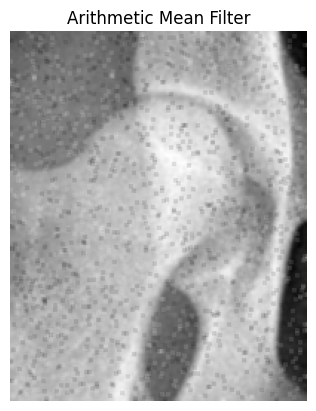

In [21]:
# 1. Arithmetic Mean Filter
def arithmetic_mean_filter(img, size):
    return cv2.blur(img, (size, size))

filtered_arithmetic = arithmetic_mean_filter(noisy_img, kernel_size)
axs[2].imshow(filtered_arithmetic, cmap='gray')
axs[2].set_title("Arithmetic Mean")

plt.imshow(filtered_arithmetic, cmap='gray')
plt.title("Arithmetic Mean Filter")
plt.axis('off')
plt.show()



Midpoint Filtering: Determines the midpoint (average of minimum and maximum) of pixel values within a kernel and assigns this midpoint to the central pixel. This method is less sensitive to outliers than the arithmetic mean filter and can preserve image edges better.

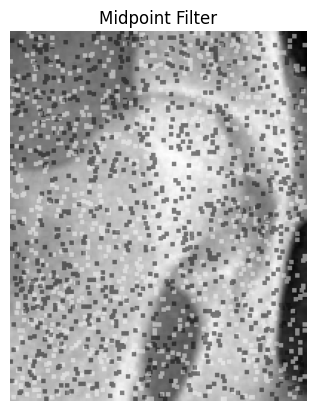

In [22]:
# 2. Midpoint Filter
def midpoint_filter(image, size):
    def filter_func(values):
        return (np.max(values) + np.min(values)) / 2
    return generic_filter(image, filter_func, size=(size, size))
    filtered_midpoint = midpoint_filter(noisy_img, kernel_size)
plt.imshow(filtered_midpoint, cmap='gray')
plt.title("Midpoint Filter")
plt.axis('off')
plt.show()


Alpha-trimmed Mean Filtering: Orders pixel values within a kernel, discards a fraction of extreme values (determined by alpha), and calculates the mean of the remaining values. This technique effectively removes outliers (noise) while preserving image details.

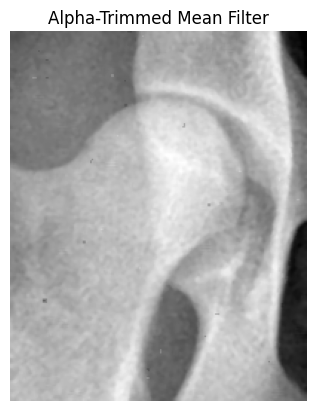

In [25]:

# 3. Alpha-trimmed Mean Filter
def alpha_trimmed_mean_filter(image, size, d):
    def filter_func(values):
        sorted_vals = np.sort(values)
        trimmed_vals = sorted_vals[d//2: -d//2]
        return np.mean(trimmed_vals)
    return generic_filter(image, filter_func, size=(size, size))
filtered_alpha = alpha_trimmed_mean_filter(noisy_img, kernel_size, d=4)
plt.imshow(filtered_alpha, cmap='gray')
plt.title("Alpha-Trimmed Mean Filter")
plt.axis('off')
plt.show()



Contraharmonic Mean Filtering: Applies a weighted average to pixel values within a kernel, where the weights depend on a parameter (Q). Positive values of Q effectively reduce pepper (dark) noise, while negative values target salt (bright) noise.

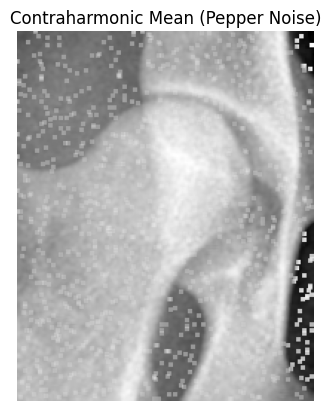

In [28]:
# 4. Contraharmonic Mean Filter (for pepper noise)
def contraharmonic_mean_filter(image, size, Q):
    def filter_func(values):
        numerator = np.sum(values**(Q+1))
        denominator = np.sum(values**Q)
        return numerator / denominator if denominator != 0 else 0
    return generic_filter(image.astype(float), filter_func, size=(size, size))
    plt.imshow(filtered_contraharmonic_pepper, cmap='gray')
plt.imshow(filtered_contraharmonic_pepper, cmap='gray')
plt.title("Contraharmonic Mean (Pepper Noise)")
plt.axis('off')
plt.show()



Combined Filtering: Applies the midpoint filter followed by the alpha-trimmed mean filter. This strategy aims to exploit the strengths of both techniques, resulting in more effective noise reduction while preserving image details.

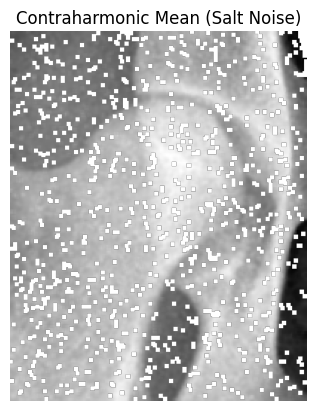

In [29]:

# Modified Contraharmonic Mean Filter for salt noise (Q < 0)
def contraharmonic_salt_removal(image, size, Q=-1.5):
    return contraharmonic_mean_filter(image, size, Q)
plt.imshow(filtered_contraharmonic_salt, cmap='gray')
plt.title("Contraharmonic Mean (Salt Noise)")
plt.axis('off')
plt.show()



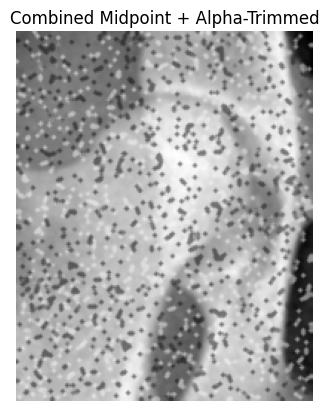

In [30]:
# Combined Midpoint + Alpha-trimmed Mean Filter
def combined_midpoint_alpha_trimmed(image, size, d):
    midpoint = midpoint_filter(image, size)
    return alpha_trimmed_mean_filter(midpoint.astype(np.uint8), size, d)
plt.imshow(filtered_contraharmonic_salt, cmap='gray')
plt.imshow(filtered_combined, cmap='gray')
plt.title("Combined Midpoint + Alpha-Trimmed")
plt.axis('off')
plt.show()


In [31]:

# Apply all filters with kernel size 3
kernel_size = 3
filtered_arithmetic = arithmetic_mean_filter(noisy_img, kernel_size)
filtered_midpoint = midpoint_filter(noisy_img, kernel_size)
filtered_alpha = alpha_trimmed_mean_filter(noisy_img, kernel_size, d=4)
filtered_contraharmonic_pepper = contraharmonic_mean_filter(noisy_img, kernel_size, Q=1.5)
filtered_contraharmonic_salt = contraharmonic_salt_removal(noisy_img, kernel_size)
filtered_combined = combined_midpoint_alpha_trimmed(noisy_img, kernel_size, d=4)


<ipython-input-28-17c3ff074d6d>:4: RuntimeWarning: divide by zero encountered in power
  numerator = np.sum(values**(Q+1))
<ipython-input-28-17c3ff074d6d>:5: RuntimeWarning: divide by zero encountered in power
  denominator = np.sum(values**Q)
<ipython-input-28-17c3ff074d6d>:6: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator if denominator != 0 else 0


 Evaluates and visualizes the effects of the different filters:

Filter Application: Applies all the defined filters to the noisy image.
Result Display: Shows the original, noisy, and filtered images together for visual comparison and assessment of filter performance.

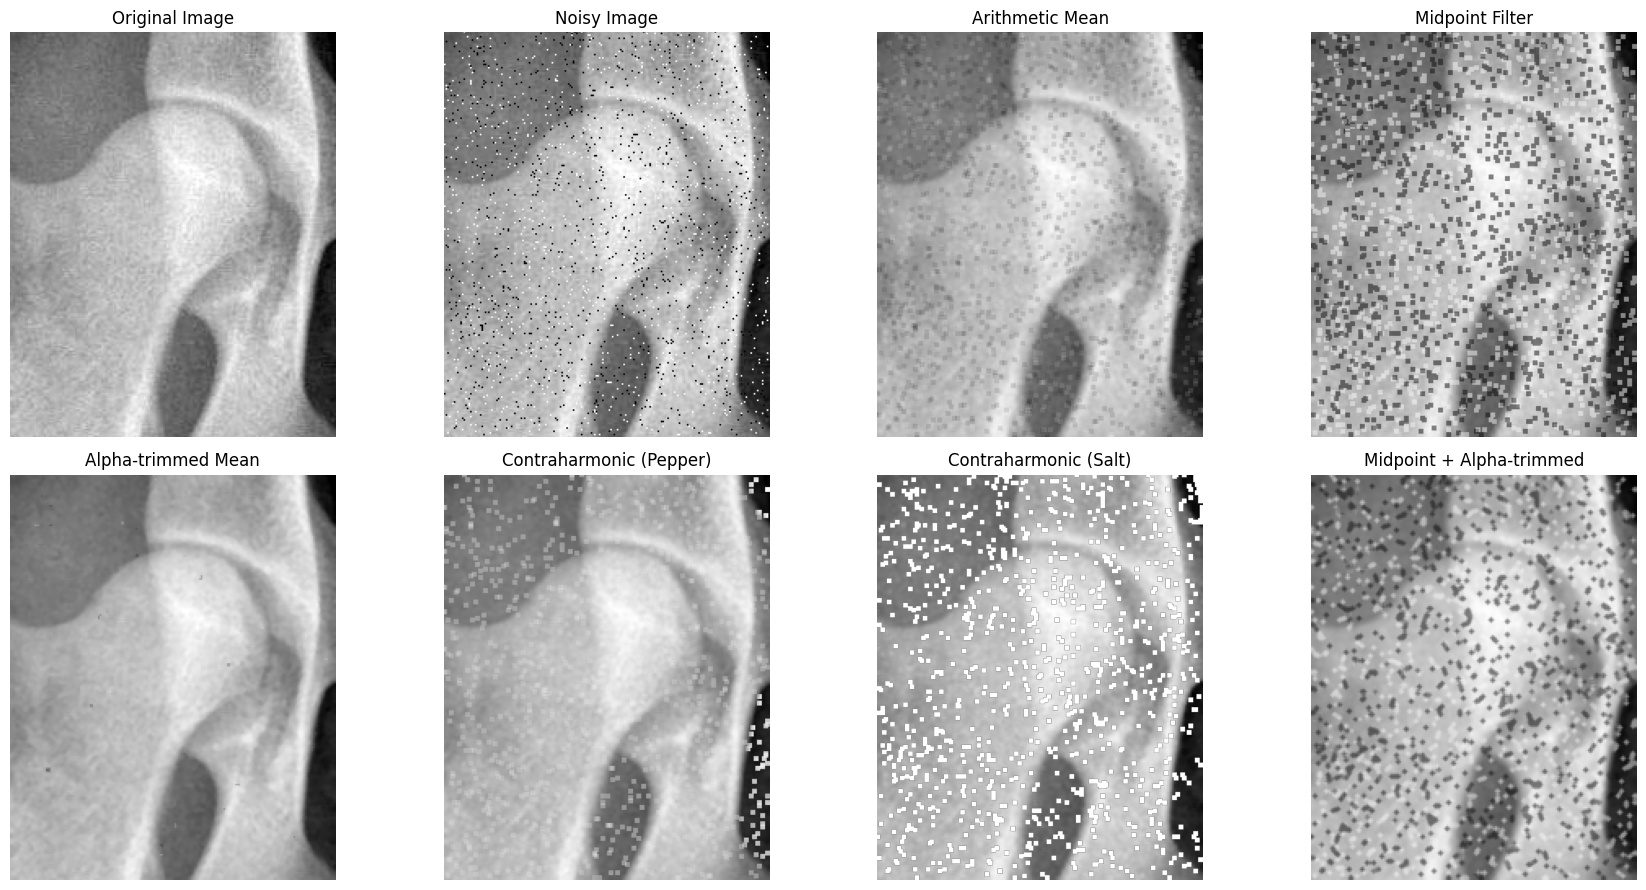

In [15]:

# Plotting the results
fig, axs = plt.subplots(2, 4, figsize=(18, 9))
axs = axs.ravel()

axs[0].imshow(img, cmap='gray')
axs[0].set_title("Original Image")
axs[1].imshow(noisy_img, cmap='gray')
axs[1].set_title("Noisy Image")

axs[2].imshow(filtered_arithmetic, cmap='gray')
axs[2].set_title("Arithmetic Mean")

axs[3].imshow(filtered_midpoint, cmap='gray')
axs[3].set_title("Midpoint Filter")

axs[4].imshow(filtered_alpha, cmap='gray')
axs[4].set_title("Alpha-trimmed Mean")

axs[5].imshow(filtered_contraharmonic_pepper, cmap='gray')
axs[5].set_title("Contraharmonic (Pepper)")

axs[6].imshow(filtered_contraharmonic_salt, cmap='gray')
axs[6].set_title("Contraharmonic (Salt)")

axs[7].imshow(filtered_combined, cmap='gray')
axs[7].set_title("Midpoint + Alpha-trimmed")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

#**Conclusion**

This report investigated various image filtering techniques for reducing salt-and-pepper noise. While simpler filters like the arithmetic mean blur the image, the midpoint and alpha-trimmed mean filters offer better edge preservation and noise reduction. The contraharmonic mean filter excels at targeting either salt or pepper noise, while combining the midpoint and alpha-trimmed filters provides a robust solution for reducing noise and preserving details. Ultimately, the choice of filter depends on the specific image and desired outcome, but the contraharmonic and combined approaches demonstrated superior performance for this type of noise.